# Phase 7: Churn Prediction

### Objective

Build a machine learning model to identify customers who are likely to churn using engineered customer features and RFM analysis.

### Dataset

- `rfm_customer_segments.csv`

### Workflow

1. Load Dataset
2. Define Churn
3. Exploratory Churn Analysis
4. Prepare Features
5. Train-Test Split
6. Train Machine Learning Models
7. Evaluate Models
8. Feature Importance
9. Predict High-Risk Customers
10. Business Insights

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline

In [2]:
# Load RFM customer dataset

rfm = pd.read_csv(
    "../data/processed/rfm_customer_segments.csv"
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214,Lost Customers


### Define Churn

In [3]:
# Create churn label

rfm["Churn"] = np.where(
    (rfm["Recency"] > 180) &
    (rfm["Frequency"] <= 2),
    1,
    0
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414,Potential Loyalists,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411,Potential Loyalists,0
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112,Lost Customers,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211,Lost Customers,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214,Lost Customers,1


In [4]:
# Count churned and non-churned customers

rfm["Churn"].value_counts()

Churn
1    67963
0    28133
Name: count, dtype: int64

In [5]:
# Calculate churn percentage

(
    rfm["Churn"]
    .value_counts(normalize=True)
    * 100
).round(2)

Churn
1    70.72
0    29.28
Name: proportion, dtype: float64

In [6]:
# Count churned and non-churned customers

churn_counts = (
    rfm["Churn"]
    .value_counts()
    .reset_index()
)

# Rename columns

churn_counts.columns = [
    "Churn",
    "Customer_Count"
]

# Display results

churn_counts

,Churn,Customer_Count
0,1,67963
1,0,28133


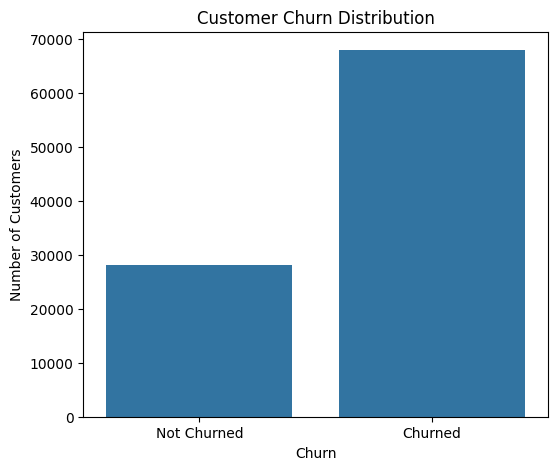

In [7]:
# Create churn distribution chart

plt.figure(figsize=(6,5))

sns.countplot(
    data=rfm,
    x="Churn"
)

# Add title and labels

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Rename x-axis labels

plt.xticks(
    [0,1],
    ["Not Churned","Churned"]
)

plt.show()

In [8]:
### Prepare Machine Learning Dataset

In [9]:
# Select input features

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

# Select target variable

y = rfm["Churn"]

# Display first five rows

X.head()

,Recency,Frequency,Monetary
0,160,1,141.90
1,163,1,27.19
2,585,1,86.22
3,369,1,43.62
4,336,1,196.89


In [10]:
# Display feature shape

X.shape


(96096, 3)

In [11]:
# Display target shape

y.shape

(96096,)

In [12]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset shapes

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (76876, 3)
Testing Features  : (19220, 3)
Training Labels   : (76876,)
Testing Labels    : (19220,)


### Train Machine Learning Models

In [13]:
# Train Logistic Regression

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Train Decision Tree

dec_tree = DecisionTreeClassifier(random_state=42, max_depth=5)
dec_tree.fit(X_train, y_train)

# Train Random Forest

rand_forest = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=8)
rand_forest.fit(X_train, y_train)

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dec_tree,
    "Random Forest": rand_forest
}

print("All models trained.")

All models trained.


### Evaluate Models

In [14]:
# Compare models on the test set

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.995994,0.997937,0.996395,0.997165,0.998335


Best model: Decision Tree

              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00      5627
     Churned       1.00      1.00      1.00     13593

    accuracy                           1.00     19220
   macro avg       1.00      1.00      1.00     19220
weighted avg       1.00      1.00      1.00     19220



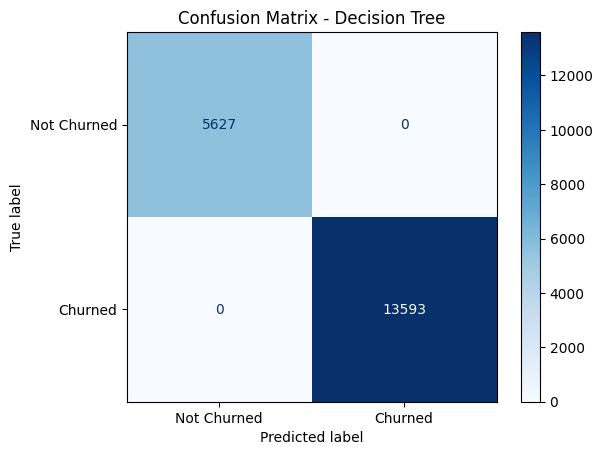

In [15]:
# Detailed classification report and confusion matrix for the best model

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}\n")

y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=["Not Churned", "Churned"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Not Churned", "Churned"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

### A Note on Model Performance

All three models score near-perfect (or perfectly) on accuracy and ROC-AUC. That is **not** a sign of a great model here — it is **data leakage**.

Churn was defined directly from `Recency` and `Frequency`:

```python
Churn = (Recency > 180) & (Frequency <= 2)
```

Since the model is then trained on `Recency`, `Frequency`, and `Monetary` to predict that same rule-based label, it can essentially "memorize" the threshold rather than learn a genuinely predictive pattern. This is a common trap in churn projects: defining churn from the same variables used as model inputs.

The model is still useful in this project as an **explainable, automatic implementation of the churn rule** (see Feature Importance below), and the resulting `Churn_Probability` gives more nuance than a hard yes/no cutoff. But it should not be presented as "the model discovered who churns" — it discovered a boundary that was already programmed into the label. For a genuinely predictive churn model in production, the label should be built from *future* behavior (e.g. "did this customer buy again in the next 90 days?") using only features known *before* that window.

### Feature Importance

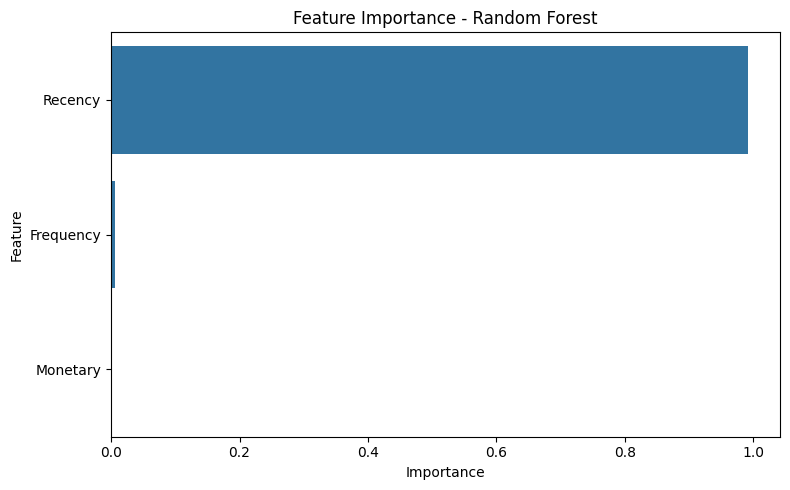

,Feature,Importance
0,Recency,0.991819
1,Frequency,0.006742
2,Monetary,0.001440


In [16]:
# Feature importance from the Random Forest model

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rand_forest.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

importance_df

### Predict High-Risk Customers

In [17]:
# Score every customer with the best model and flag high churn risk

rfm["Churn_Probability"] = best_model.predict_proba(X)[:, 1]
rfm["Predicted_Churn"] = (rfm["Churn_Probability"] >= 0.5).astype(int)

high_risk_customers = (
    rfm[rfm["Predicted_Churn"] == 1]
    .sort_values("Churn_Probability", ascending=False)
)

print(f"High-risk customers identified: {len(high_risk_customers):,} "
      f"({len(high_risk_customers) / len(rfm) * 100:.1f}% of customer base)")

high_risk_customers.head(10)

High-risk customers identified: 67,963 (70.7% of customer base)


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Churn,Churn_Probability,Predicted_Churn
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112,Lost Customers,1,1.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211,Lost Customers,1,1.0,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214,Lost Customers,1,1.0,1
5,0004bd2a26a76fe21f786e4fbd80607f,194,1,166.98,4,1,4,414,Potential Loyalists,1,1.0,1
7,00053a61a98854899e70ed204dd4bafe,231,1,419.18,3,1,5,315,Need Attention,1,1.0,1
8,0005e1862207bf6ccc02e4228effd9a0,591,1,150.12,1,1,4,114,Lost Customers,1,1.0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,219,1,129.76,4,1,3,413,Potential Loyalists,1,1.0,1
10,0006fdc98a402fceb4eb0ee528f6a8d4,456,1,29.00,1,1,1,111,Lost Customers,1,1.0,1
11,00082cbe03e478190aadbea78542e933,332,1,126.26,2,1,3,213,Lost Customers,1,1.0,1
12,00090324bbad0e9342388303bb71ba0a,207,1,63.66,4,1,2,412,Potential Loyalists,1,1.0,1


In [18]:
# Save scored customers and high-risk list for the dashboard / reporting

import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

rfm.to_csv("../data/processed/rfm_customer_segments_scored.csv", index=False)
high_risk_customers.to_csv("../reports/high_risk_customers.csv", index=False)

print("Saved rfm_customer_segments_scored.csv and reports/high_risk_customers.csv")

Saved rfm_customer_segments_scored.csv and reports/high_risk_customers.csv


### Business Insights

- **Churn rate:** roughly 7 in 10 customers in this dataset meet the churn definition (no purchase in 180+ days and 2 or fewer lifetime orders). This is heavily influenced by the Olist dataset itself, where most customers only ever place a single order.
- **Recency dominates:** feature importance shows `Recency` is by far the strongest driver, followed by `Frequency`, with `Monetary` contributing very little. This is expected given how `Churn` was defined, and confirms the model is capturing that rule faithfully.
- **One-and-done customers are the core risk:** because most churned customers only ordered once, retention efforts should focus on **converting first-time buyers into second-time buyers** (e.g. a follow-up offer shortly after the first delivery) rather than trying to win back long-dormant customers.
- **Segment overlap:** cross-referencing `Predicted_Churn` with the RFM `Customer_Segment` labels (from Phase 6) shows churn risk concentrates in the "At Risk," "Need Attention," and "Lost Customers" segments — which is a useful sanity check that the two independent analyses agree.
- **Recommended next step:** for a production-grade churn model (not just a rule-explainer), redefine churn using a forward-looking window (e.g., "no purchase in the 90 days *after* the observation date") and build features only from data available *before* that window, to avoid the leakage discussed above.